## Imports

In [22]:
import string
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import nltk
from nltk.corpus import stopwords, gutenberg
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('gutenberg')

[nltk_data] Downloading package punkt to /home/russy/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/russy/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /home/russy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package gutenberg to /home/russy/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!


True

## Corpus & Preprocessing

In [23]:
string_list = [
    "The cat is sleeping on the sofa in the house.",
    "The dog is sleeping on the floor in the house.",
    "The cat is resting on the bed in the bedroom.",
    "The dog is resting on the rug in the bedroom.",
    "The cat is sitting by the window in the kitchen.",
    "The dog is sitting by the door in the kitchen.",
]

corpus = [sentence.split() for sentence in string_list]
print(corpus)

[['The', 'cat', 'is', 'sleeping', 'on', 'the', 'sofa', 'in', 'the', 'house.'], ['The', 'dog', 'is', 'sleeping', 'on', 'the', 'floor', 'in', 'the', 'house.'], ['The', 'cat', 'is', 'resting', 'on', 'the', 'bed', 'in', 'the', 'bedroom.'], ['The', 'dog', 'is', 'resting', 'on', 'the', 'rug', 'in', 'the', 'bedroom.'], ['The', 'cat', 'is', 'sitting', 'by', 'the', 'window', 'in', 'the', 'kitchen.'], ['The', 'dog', 'is', 'sitting', 'by', 'the', 'door', 'in', 'the', 'kitchen.']]


In [24]:
def preprocess_corpus(corpus: list) -> tuple:
    """
    Preprocess the corpus removing stopwords, punctuation.
    Then map each token to an int, save both mappings and return a list of list of 
    ints representing the sentences in the corpus

    Args:
        corpus: list of list of strings representing the sentences in the corpus

    Returns:
        tuple of (word2idx, idx2word, encoded_corpus) where:
            word2idx dict provides a string to int mapping
            idx2word dict provides a int to string mapping
            encoded_corpus list contains int-encoded sentences in the corpus
    """
    
    index = 0
    word2idx = {}
    idx2word = {}
    encoded_corpus = []
    stop_words = set(stopwords.words('english'))
    
    for sentence in corpus:
        
        encoded_sentence = []
        
        for word in sentence:
                        
            # lowercase the word
            word = word.lower()
            
            # remove punctuation
            word = word.translate(str.maketrans('', '', string.punctuation))
            
            # remove stopwords
            if word in stop_words:
                continue
            
            # add word to the mappings if not already present
            if word not in word2idx:
                word2idx[word] = index
                idx2word[index] = word
                index += 1
                
            # add the int encoding of the word to the encoded sentence
            encoded_sentence.append(word2idx[word])
            
        encoded_corpus.append(encoded_sentence)
    
    return word2idx, idx2word, encoded_corpus

word2idx, idx2word, encoded_corpus = preprocess_corpus(corpus=corpus)
print(word2idx)
print(idx2word)
print(encoded_corpus)

{'cat': 0, 'sleeping': 1, 'sofa': 2, 'house': 3, 'dog': 4, 'floor': 5, 'resting': 6, 'bed': 7, 'bedroom': 8, 'rug': 9, 'sitting': 10, 'window': 11, 'kitchen': 12, 'door': 13}
{0: 'cat', 1: 'sleeping', 2: 'sofa', 3: 'house', 4: 'dog', 5: 'floor', 6: 'resting', 7: 'bed', 8: 'bedroom', 9: 'rug', 10: 'sitting', 11: 'window', 12: 'kitchen', 13: 'door'}
[[0, 1, 2, 3], [4, 1, 5, 3], [0, 6, 7, 8], [4, 6, 9, 8], [0, 10, 11, 12], [4, 10, 13, 12]]


## Skip-gram Pair Generation

In [25]:
def generate_skipgram_pairs(corpus: list, window_size: int) -> tuple:
    """
    Generate skipgram pairs from the encoded corpus

    Args:
        corpus: list of list of ints representing the sentences in the corpus
        window_size (int): size of the context window
    Returns:
        centers, contexts: list of center words and list of context words
    """
    
    centers, contexts = [], []
    
    for sentence in corpus:
        for i, center in enumerate(sentence):
            left = max(0, i - window_size)
            right = min(len(sentence), i + window_size + 1)
            
            for j in range(left, right):
                if i != j:
                    centers.append(center)
                    contexts.append(sentence[j])
      
    return centers, contexts

x, y = generate_skipgram_pairs(corpus=encoded_corpus, window_size=5)

## PyTorch Implementation (Full Softmax)

In [26]:
class SkipGramSoftmax(nn.Module):
    
    def __init__(self, vocab_size, emb_dim):
        super().__init__()
        
        self.vocab_size = vocab_size
        self.emb_dim = emb_dim
        
        self.W1 = nn.Embedding(vocab_size, emb_dim)
        self.W2 = nn.Linear(emb_dim, vocab_size)
        
    def forward(self, x):
        
        h = self.W1(x)
        out = self.W2(h)
        
        return out

### Testing the softmax implementation

In [27]:
epochs = 500
batch_size = 1
embedding_dim = 16

vocab_size = len(word2idx)
model = SkipGramSoftmax(vocab_size, embedding_dim)
loss = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.01)

x_tensor = torch.LongTensor(x)
y_tensor = torch.LongTensor(y)

for epoch in range(epochs):
    total_loss = 0
    
    # shuffle training pairs each epoch
    perm = torch.randperm(len(x_tensor))
    x_shuffled = x_tensor[perm]
    y_shuffled = y_tensor[perm]
    
    for i in range(0, len(x_shuffled), batch_size):
        x_batch = x_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        
        optimizer.zero_grad()
        
        logits = model(x_batch)
        batch_loss = loss(logits, y_batch)
        batch_loss.backward()
        optimizer.step()
        
        total_loss += batch_loss.item()
        
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}")

Epoch 50/500, Loss: 135.1531
Epoch 100/500, Loss: 134.4889
Epoch 150/500, Loss: 134.5650
Epoch 200/500, Loss: 133.5556
Epoch 250/500, Loss: 132.5841
Epoch 300/500, Loss: 132.4733
Epoch 350/500, Loss: 131.6453
Epoch 400/500, Loss: 132.4072
Epoch 450/500, Loss: 131.3756
Epoch 500/500, Loss: 129.8726


In [28]:
from adjustText import adjust_text

def plot_embeddings(embeddings, idx2word, method='pca'):
    if method == 'pca':
        reducer = PCA(n_components=2)
    elif method == 'tsne':
        reducer = TSNE(n_components=2, random_state=42)
    else:
        raise ValueError("Method must be 'pca' or 'tsne'")
    
    reduced_embeddings = reducer.fit_transform(embeddings)
    
    plt.figure(figsize=(10, 10))
    texts = []
    for i in range(len(reduced_embeddings)):
        plt.scatter(reduced_embeddings[i, 0], reduced_embeddings[i, 1])
        texts.append(plt.text(reduced_embeddings[i, 0], reduced_embeddings[i, 1], idx2word[i]))

    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

    plt.title(f"Word Embeddings Visualized with {method.upper()}")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.grid()
    plt.show()

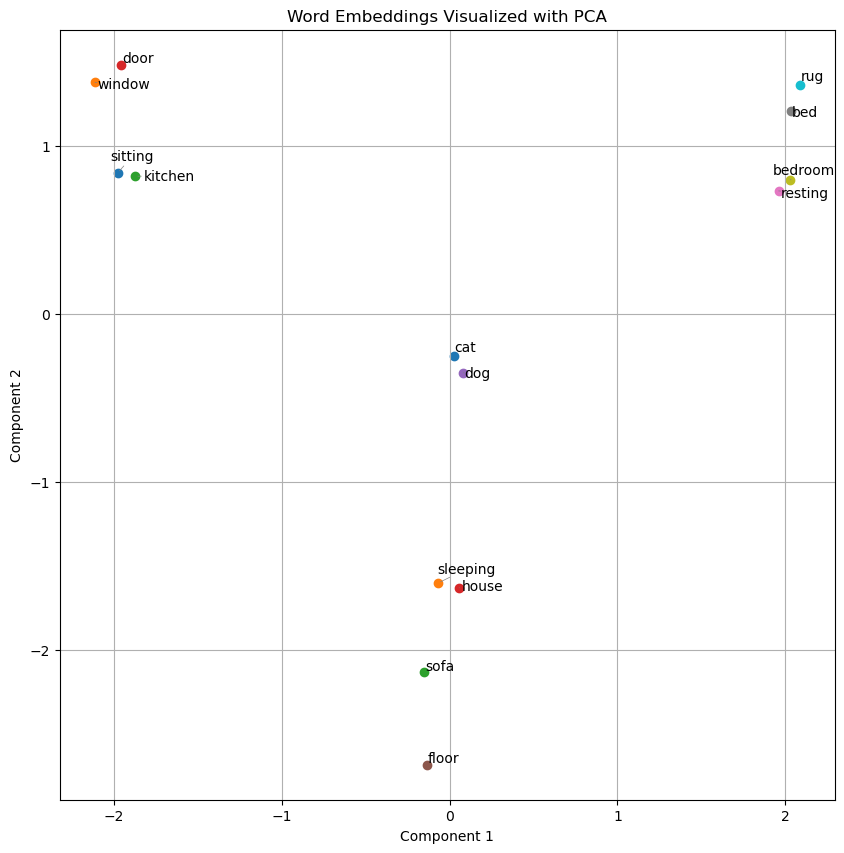

In [29]:
plot_embeddings(model.W1.weight.data.numpy(), idx2word, method='pca')

## NumPy Implementation (Full Softmax)

In [30]:
class SkipGramSoftmaxNumpy:
    """
    A naive implementation of the skip-gram word2vec model using only numpy.
    Uses Xavier initialization for the weights and a numerically stable softmax.
    """
    
    
    def __init__(self, vocab_size: int, emb_dim: int):
        self.vocab_size = vocab_size
        self.emb_dim = emb_dim
        
        # Xavier initialization
        scale = np.sqrt(2.0 / (vocab_size + emb_dim))
        self.W1 = np.random.randn(vocab_size, emb_dim) * scale  # input embeddings (V, d)
        self.W2 = np.random.randn(vocab_size, emb_dim) * scale  # output weights (V, d)
    
    def softmax(self, z: np.ndarray) -> np.ndarray:
        
        # numerically unstable softmax
        # return np.exp(z) / np.sum(np.exp(z), axis=-1, keepdims=True)
        
        # numerically stable softmax
        z_shifted = z - np.max(z, axis=-1, keepdims=True)
        exp_z = np.exp(z_shifted)
        return exp_z / np.sum(exp_z, axis=-1, keepdims=True)
    
    def forward(self, center_idx: int) -> tuple:
        """
        Forward pass for a single training pair.
        
        Args:
            center_idx: index of the center word
        Returns:
            v_c: input embedding of center word (d,)
            y_hat: predicted probability distribution over vocab (V,)
        """
        v_c = self.W1[center_idx]           # (d,)
        z = self.W2 @ v_c                   # (V, d) @ (d,) = (V,)
        y_hat = self.softmax(z)             # (V,)
        return v_c, y_hat
    
    def compute_loss(self, y_hat: np.ndarray, context_idx: int) -> float:
        return -np.log(y_hat[context_idx] + 1e-10)
    
    def backward(self, y_hat: np.ndarray, center_idx: int, context_idx: int) -> tuple:
        """
        Compute gradients using the derived formulas.
        
        dL/du_w = (y_hat_w - 1[w=o]) * v_c        for each output vector
        dL/dv_c = sum_w (y_hat_w - 1[w=o]) * u_w   for the input vector
        
        Args:
            y_hat: predicted distribution (V,)
            center_idx: index of center word
            context_idx: index of true context word
        Returns:
            dW1: gradient for W1 row center_idx (d,)
            dW2: gradient for W2 (V, d)
        """
        # gradient of loss w.r.t. scores := y_hat - one_hot(context)
        dl_dz = y_hat.copy()                # (V,)
        dl_dz[context_idx] -= 1.0                   
        
        # dL/dW2 = dl_dz (outer) v_c -> (V, d)
        v_c = self.W1[center_idx]            # (d,)
        dW2 = np.outer(dl_dz, v_c)          # (V, d)
        
        # dL/dv_c = W2.T @ dl_dz -> (d,)
        dW1 = self.W2.T @ dl_dz             # (d, V) @ (V,) = (d,)
        
        return dW1, dW2
    
    def train(self, centers: list, contexts: list, epochs: int = 500, lr: float = 0.01):
        """
        Train the model using SGD.
        
        Args:
            centers: list of center word indices
            contexts: list of context word indices
            epochs: number of training epochs
            lr: learning rate
        """
        pairs = np.array(list(zip(centers, contexts)))
        
        for epoch in range(epochs):
            total_loss = 0.0
            np.random.shuffle(pairs)
            
            for center_idx, context_idx in pairs:
                # forward
                v_c, y_hat = self.forward(center_idx)
                total_loss += self.compute_loss(y_hat, context_idx)
                
                # backward
                dW1, dW2 = self.backward(y_hat, center_idx, context_idx)
                
                # update
                self.W1[center_idx] -= lr * dW1
                self.W2 -= lr * dW2
            
            if (epoch + 1) % 50 == 0:
                print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}")

### Testing the softmax implementation

Epoch 50/500, Loss: 154.7456
Epoch 100/500, Loss: 130.5659
Epoch 150/500, Loss: 123.6861
Epoch 200/500, Loss: 121.8157
Epoch 250/500, Loss: 121.1337
Epoch 300/500, Loss: 120.8022
Epoch 350/500, Loss: 120.6805
Epoch 400/500, Loss: 120.6027
Epoch 450/500, Loss: 120.5182
Epoch 500/500, Loss: 120.5353


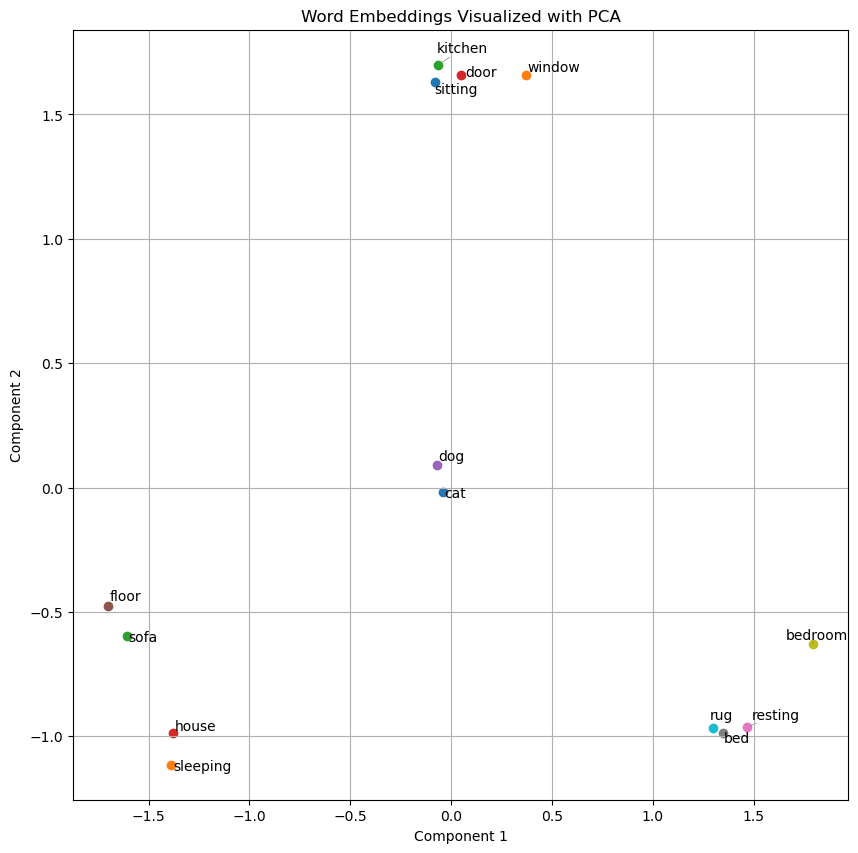

In [31]:
model = SkipGramSoftmaxNumpy(vocab_size=len(word2idx), emb_dim=embedding_dim)
model.train(centers=x, contexts=y, epochs=epochs, lr=0.01)

embeddings = model.W1
plot_embeddings(embeddings, idx2word, method='pca')

## PyTorch Implementation (Negative Sampling)

### Samplers

In [32]:
class UniformNegativeSampler:
    """Samples negatives uniformly for torch or numpy workflows."""

    def __init__(self, vocab_size, num_negatives=5, backend='torch'):
        self.vocab_size = vocab_size
        self.num_negatives = num_negatives
        self.backend = backend

    def sample(self, batch_size, positive_context=None):
        """Returns random indices of shape (batch_size, num_negatives)."""
        if self.backend == 'torch':
            return torch.randint(0, self.vocab_size, (batch_size, self.num_negatives))
        if self.backend == 'numpy':
            return np.random.randint(0, self.vocab_size, size=(batch_size, self.num_negatives), dtype=np.int64)
        raise ValueError("backend must be 'torch' or 'numpy'")


class UnigramNegativeSampler:
    """Samples negatives from a unigram^0.75 distribution."""

    def __init__(
        self,
        vocab_size,
        num_negatives,
        unigram_counts,
        power=0.75,
        backend='torch',
    ):
        self.vocab_size = vocab_size
        self.num_negatives = num_negatives
        self.backend = backend
        self.power = power

        counts = np.asarray(unigram_counts, dtype=np.float64)
        if counts.shape[0] != vocab_size:
            raise ValueError("unigram_counts must have length vocab_size")
        probs = np.power(np.maximum(counts, 1.0), power)
        probs = probs / probs.sum()

        self._probs_np = probs
        self._probs_torch = torch.tensor(probs, dtype=torch.float32)

    def _sample_torch(self, n_samples):
        return torch.multinomial(self._probs_torch, n_samples, replacement=True)

    def _sample_numpy(self, n_samples):
        return np.random.choice(
            self.vocab_size,
            size=n_samples,
            replace=True,
            p=self._probs_np,
        )

    def sample(self, batch_size, positive_context):
        """Returns random indices of shape (batch_size, num_negatives)."""
        n_samples = batch_size * self.num_negatives

        if self.backend == 'torch':
            neg = self._sample_torch(n_samples).view(batch_size, self.num_negatives)

            # Keep negatives distinct from true context words
            positive_context = positive_context.to(neg.device)
            mask = neg.eq(positive_context.unsqueeze(1))
            while mask.any():
                neg[mask] = self._sample_torch(int(mask.sum().item()))
                mask = neg.eq(positive_context.unsqueeze(1))

            return neg

        if self.backend == 'numpy':
            neg = self._sample_numpy(n_samples).reshape(batch_size, self.num_negatives)

            positive_context = np.asarray(positive_context).reshape(-1)
            mask = neg == positive_context[:, None]
            while mask.any():
                neg[mask] = self._sample_numpy(mask.sum())
                mask = neg == positive_context[:, None]

            return neg.astype(np.int64)

        raise ValueError("backend must be 'torch' or 'numpy'")


In [33]:


class SkipGramNegSampling(nn.Module):

    def __init__(self, vocab_size, emb_dim):
        super().__init__()

        # W1: input embeddings  (V, d)
        # W2: output embeddings (V, d)
        self.W1 = nn.Embedding(vocab_size, emb_dim)
        self.W2 = nn.Embedding(vocab_size, emb_dim)
    
    def forward(self, center, context, neg_indices):
        """
        Computes the negative sampling loss.
        Loss = -log sigma(u_o^T v_c) - sum(log sigma(-u_n^T v_c))

        Args:
            center:      (batch,)  center word indices
            context:     (batch,)  true context word indices
            neg_indices: (batch, k) pre-sampled negative word indices
        Returns:
            loss: scalar, mean negative sampling loss over the batch
        """
        # look up embeddings
        v_c = self.W1(center)                # (batch, d)
        u_o = self.W2(context)               # (batch, d)
        u_n = self.W2(neg_indices)           # (batch, k, d)

        # positive term: -log sigma(u_o^T v_c)
        pos_score = (v_c * u_o).sum(dim=1)   # (batch,)
        pos_log_prob = F.logsigmoid(pos_score)

        # negative terms: -sum(log sigma(-u_n^T v_c))
        neg_score = (v_c.unsqueeze(1) * u_n).sum(dim=2)  # (batch, k)
        neg_log_prob = F.logsigmoid(-neg_score).sum(dim=1)

        loss = -(pos_log_prob + neg_log_prob).mean()

        return loss

### Testing the negative sampling implementation

In [ ]:
# load Gutenberg texts as sentences
raw_corpus = []
for fileid in ['austen-emma.txt']:
    raw_corpus.extend(gutenberg.sents(fileid))

g_word2idx, g_idx2word, g_encoded_corpus = preprocess_corpus(raw_corpus)
print(f"Vocab size: {len(g_word2idx)}")
print(f"Total sentences: {len(g_encoded_corpus)}")

# generate skipgram pairs
g_centers, g_contexts = generate_skipgram_pairs(g_encoded_corpus, window_size=3)
print(f"Training pairs: {len(g_centers)}")

# train
g_epochs = 50
g_batch_size = 1024
g_emb_dim = 128
g_num_negatives = 10
g_vocab_size = len(g_word2idx)

# Build unigram counts aligned with vocabulary indices.
g_counts = np.zeros(g_vocab_size, dtype=np.float64)
for sent in g_encoded_corpus:
    for token_id in sent:
        g_counts[token_id] += 1.0

torch.manual_seed(42)
g_model = SkipGramNegSampling(g_vocab_size, g_emb_dim)
g_sampler = UnigramNegativeSampler(
    g_vocab_size,
    g_num_negatives,
    unigram_counts=g_counts,
    backend='torch'
)
g_optimizer = optim.AdamW(g_model.parameters(), lr=0.002, weight_decay=1e-4)

g_x = torch.LongTensor(g_centers)
g_y = torch.LongTensor(g_contexts)

for epoch in range(g_epochs):
    total_loss = 0.0

    perm = torch.randperm(len(g_x))
    g_x_shuffled = g_x[perm]
    g_y_shuffled = g_y[perm]

    for i in range(0, len(g_x_shuffled), g_batch_size):
        x_batch = g_x_shuffled[i:i + g_batch_size]
        y_batch = g_y_shuffled[i:i + g_batch_size]
        neg_batch = g_sampler.sample(x_batch.shape[0], positive_context=y_batch)

        g_optimizer.zero_grad()
        loss = g_model(x_batch, y_batch, neg_batch)
        loss.backward()
        g_optimizer.step()

        total_loss += loss.item() * x_batch.shape[0]

    avg_loss = total_loss / len(g_x)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{g_epochs}, Avg Loss: {avg_loss:.4f}")

# visualize top 100 most common words
word_counts = Counter()
for sent in g_encoded_corpus:
    word_counts.update(sent)

top_100 = [idx for idx, _ in word_counts.most_common(100)]
top_embeddings = g_model.W1.weight.data.numpy()[top_100]
top_idx2word = {i: g_idx2word[idx] for i, idx in enumerate(top_100)}

plot_embeddings(top_embeddings, top_idx2word, method='pca')

In [ ]:
plot_embeddings(top_embeddings, top_idx2word, method='tsne')

## Numpy Implementation (Negative Sampling)

In [36]:
class SkipGramNegSamplingNumpy:
    """
    An implmentation of skip-gram with negative sampling using only numpy.
    """
    
    def __init__(self, vocab_size: int, emb_dim: int):
        self.vocab_size = vocab_size
        self.emb_dim = emb_dim
        
        # Xavier initialization
        scale = np.sqrt(2.0 / (vocab_size + emb_dim))
        self.W1 = np.random.randn(vocab_size, emb_dim) * scale  # input embeddings (V, d)
        self.W2 = np.random.randn(vocab_size, emb_dim) * scale  # output embeddings (V, d)
        
    def sigmoid(self, x):
        # numrically unstable sigmoid
        # return 1 / (1 + np.exp(-x))
    
        # numerically stable sigmoid
        return np.where(x >= 0,
                        1.0 / (1.0 + np.exp(-x)),
                        np.exp(x) / (1.0 + np.exp(x)))
    
    def forward(self, center_idx: int, context_idx: int, neg_indices: np.ndarray) -> float:
        """
        Computes the negative sampling loss.
        Loss = -log sigma(u_o^T v_c) - sum(log sigma(-u_n^T v_c))

        Args:
            center_idx (int): index of the center word
            context_idx (int): index of the true context word
            neg_indices (np.ndarray): array of shape (k,) containing indices of negative samples

        Returns:
            float: the negative sampling loss for this training pair
        """
        
        v_c = self.W1[center_idx]           # (d,)
        u_o = self.W2[context_idx]          # (d,)
        u_n = self.W2[neg_indices]          # (k, d)
        
        # positive term
        pos_score = np.dot(u_o, v_c)        # scalar
        pos_loss = -np.log(self.sigmoid(pos_score) + 1e-10)
        
        # negative terms
        neg_scores = np.dot(u_n, v_c)       # (k,)
        neg_loss = -np.sum(np.log(self.sigmoid(-neg_scores) + 1e-10))
        
        return pos_score, neg_scores, pos_loss + neg_loss
    
    def backward(self, center_idx: int, context_idx: int, neg_indices: np.ndarray, pos_score: float, neg_scores: np.ndarray) -> tuple:
        """
        Compute gradients for W1 and W2 using the derived formulas.
        
        dL/du_o   = (sigma(u_o^T v_c) - 1) * v_c
        dL/du_n_i = sigma(u_n_i^T v_c) * v_c
        dL/dv_c   = (sigma(u_o^T v_c) - 1) * u_o + sum(sigma(u_n_i^T v_c) * u_n_i)
        
        Args:
            center_idx (int): index of the center word
            context_idx (int): index of the true context word
            neg_indices (np.ndarray): array of shape (k,) containing indices of negative samples
            
        Returns:
            dv_c:  gradient for W1 row center_idx (d,)
            du_o:  gradient for W2 row context_idx (d,)
            du_n:  gradient for W2 rows neg_indices (k, d)
        """
        
        v_c = self.W1[center_idx]           # (d,)
        u_o = self.W2[context_idx]          # (d,)
        u_n = self.W2[neg_indices]          # (k, d)
        
        # sigmoid coefficients
        sig_pos = self.sigmoid(pos_score)    # scalar
        sig_neg = self.sigmoid(neg_scores)   # (k,)
        
        # dL/du_o = (sigma(s_o) - 1) * v_c
        du_o = (sig_pos - 1) * v_c           # (d,)
        
        # dL/du_n_i = sigma(s_n_i) * v_c for each negative
        du_n = np.outer(sig_neg, v_c)        # (k, d)
        
        # dL/dv_c = (sigma(s_o) - 1) * u_o + sum(sigma(s_n_i) * u_n_i)
        dv_c = (sig_pos - 1) * u_o + (sig_neg @ u_n)  # (d,)
        
        return dv_c, du_o, du_n

    def train_one_epoch(self, centers: np.ndarray, contexts: np.ndarray, sampler, batch_size: int, lr: float) -> float:
        """Train for one epoch and return average loss."""
        if len(centers) == 0:
            return 0.0

        perm = np.random.permutation(len(centers))
        x_shuffled = centers[perm]
        y_shuffled = contexts[perm]

        total_loss = 0.0

        for i in range(0, len(x_shuffled), batch_size):
            x_batch = x_shuffled[i:i + batch_size]
            y_batch = y_shuffled[i:i + batch_size]
            neg_batch = sampler.sample(len(x_batch), positive_context=y_batch)

            for center_idx, context_idx, neg_indices in zip(x_batch, y_batch, neg_batch):
                pos_score, neg_scores, loss = self.forward(center_idx, context_idx, neg_indices)
                dv_c, du_o, du_n = self.backward(center_idx, context_idx, neg_indices, pos_score, neg_scores)

                self.W1[center_idx] -= lr * dv_c
                self.W2[context_idx] -= lr * du_o
                
                # This doesn't handle the case where the same negative sample appears multiple times in neg_indices
                # self.W2[neg_indices] -= lr * du_n

                # handle duplicate negative samples by accumulating gradients for each unique index
                np.add.at(self.W2, neg_indices, -lr * du_n)

                total_loss += loss

        return total_loss / len(centers)

### Testing the negative sampling implementation

In [40]:
# load Gutenberg texts as sentences
raw_corpus = []
for fileid in ['austen-emma.txt']:
    raw_corpus.extend(gutenberg.sents(fileid))

g_word2idx, g_idx2word, g_encoded_corpus = preprocess_corpus(raw_corpus)
print(f"Vocab size: {len(g_word2idx)}")
print(f"Total sentences: {len(g_encoded_corpus)}")

# generate skipgram pairs
g_centers, g_contexts = generate_skipgram_pairs(g_encoded_corpus, window_size=5)
print(f"Training pairs: {len(g_centers)}")

# train
g_epochs = 20
g_batch_size = 512
g_emb_dim = 128
g_num_negatives = 5
g_vocab_size = len(g_word2idx)
g_lr = 0.005

# Build unigram counts aligned with vocabulary indices.
g_counts = np.zeros(g_vocab_size, dtype=np.float64)
for sent in g_encoded_corpus:
    for token_id in sent:
        g_counts[token_id] += 1.0

g_model = SkipGramNegSamplingNumpy(g_vocab_size, g_emb_dim)
g_sampler = UnigramNegativeSampler(
    g_vocab_size,
    g_num_negatives,
    unigram_counts=g_counts,
    backend='numpy',
)

g_centers_np = np.array(g_centers, dtype=np.int64)
g_contexts_np = np.array(g_contexts, dtype=np.int64)

for epoch in range(g_epochs):
    avg_loss = g_model.train_one_epoch(
        centers=g_centers_np,
        contexts=g_contexts_np,
        sampler=g_sampler,
        batch_size=g_batch_size,
        lr=g_lr,
    )
    print(f"Epoch {epoch+1}/{g_epochs}, Avg Loss: {avg_loss:.4f}")

# visualize top 100 most common words
word_counts = Counter()
for sent in g_encoded_corpus:
    word_counts.update(sent)

top_100 = [idx for idx, _ in word_counts.most_common(100)]
top_embeddings = g_model.W1[top_100]
top_idx2word = {i: g_idx2word[idx] for i, idx in enumerate(top_100)}

Vocab size: 6973
Total sentences: 7752
Training pairs: 815866
Epoch 1/20, Avg Loss: 3.4491
Epoch 2/20, Avg Loss: 2.8439
Epoch 3/20, Avg Loss: 2.6564
Epoch 4/20, Avg Loss: 2.5721
Epoch 5/20, Avg Loss: 2.5250
Epoch 6/20, Avg Loss: 2.4952
Epoch 7/20, Avg Loss: 2.4728
Epoch 8/20, Avg Loss: 2.4551
Epoch 9/20, Avg Loss: 2.4418
Epoch 10/20, Avg Loss: 2.4290
Epoch 11/20, Avg Loss: 2.4183
Epoch 12/20, Avg Loss: 2.4081
Epoch 13/20, Avg Loss: 2.3984
Epoch 14/20, Avg Loss: 2.3894
Epoch 15/20, Avg Loss: 2.3809
Epoch 16/20, Avg Loss: 2.3712
Epoch 17/20, Avg Loss: 2.3616
Epoch 18/20, Avg Loss: 2.3530
Epoch 19/20, Avg Loss: 2.3441
Epoch 20/20, Avg Loss: 2.3341


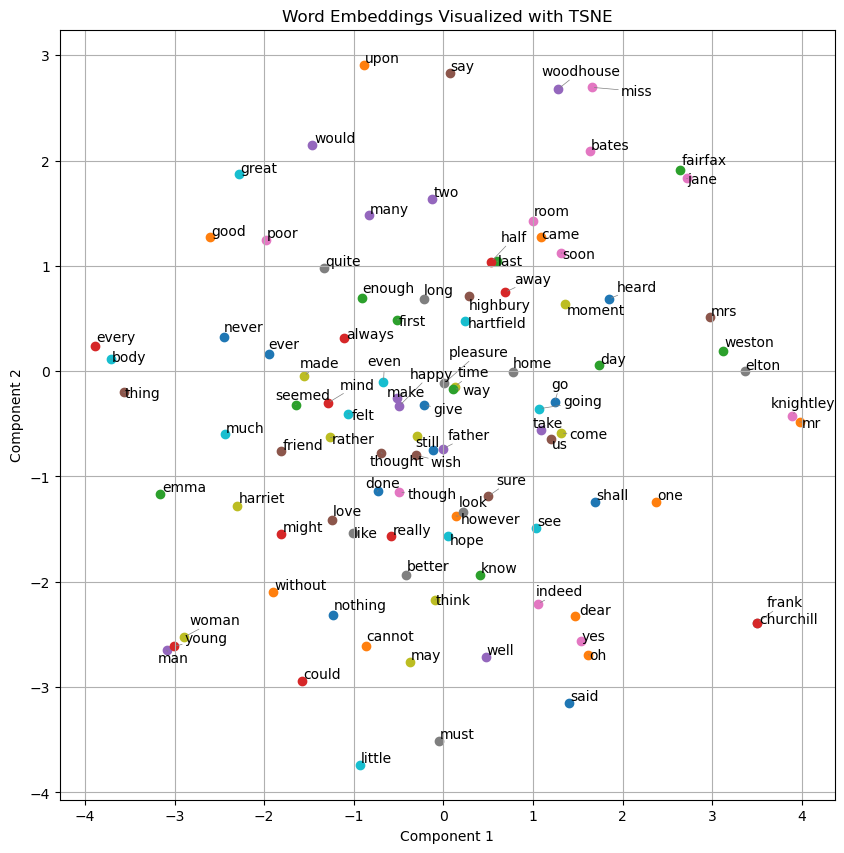

In [39]:
plot_embeddings(top_embeddings, top_idx2word, method='tsne')